# Injecting Knowledge Graphs into Large Language Models
## Implementación del paper: *"Let Your Graph Do the Reasoning"* (Coppolillo, 2025)

Este notebook implementa el framework propuesto en el paper, adaptado al Knowledge Graph de incidencias (`filtrado.ttl`).

**Pipeline:**
1. Carga y parseo del KG desde `.ttl`
2. Entrenamiento de un modelo KGE (TransE, DistMult, ComplEx o RotatE)
3. Generación del embedding del KG mediante agregación columnar
4. Proyección al espacio de tokens del LLM (capa densa)
5. Inyección del embedding en el LLM congelado y respuesta a preguntas

## 0. Instalación de dependencias

In [ ]:
!pip install rdflib torch transformers peft scikit-learn matplotlib seaborn tqdm -q

## 1. Carga del Knowledge Graph desde `.ttl`

In [ ]:
import rdflib
from rdflib import Graph, URIRef
from collections import defaultdict
import re

TTL_PATH = "filtrado.ttl"  # Ajusta la ruta si es necesario

g = Graph()
g.parse(TTL_PATH, format="turtle")
print(f"Triples cargados: {len(g)}")

# Extraer todas las triples (head, relation, tail)
triples_raw = [(str(s), str(p), str(o)) for s, p, o in g]
print(f"Ejemplo de triple: {triples_raw[0]}")

Triples cargados: 513651
Ejemplo de triple: ('http://repcon.org/schema#incident_1497610467941762304069', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', 'http://repcon.org/schema#incident')


In [ ]:
# Mapear entidades y relaciones a índices enteros

entities = set()
relations = set()

for h, r, t in triples_raw:
    entities.add(h)
    entities.add(t)
    relations.add(r)

entity2id = {e: i for i, e in enumerate(sorted(entities))}
relation2id = {r: i for i, r in enumerate(sorted(relations))}
id2entity = {v: k for k, v in entity2id.items()}
id2relation = {v: k for k, v in relation2id.items()}

triples = [(entity2id[h], relation2id[r], entity2id[t]) for h, r, t in triples_raw]

n_entities = len(entity2id)
n_relations = len(relation2id)
n_triples = len(triples)

print(f"Entidades únicas: {n_entities}")
print(f"Relaciones únicas: {n_relations}")
print(f"Triples: {n_triples}")

Entidades únicas: 60762
Relaciones únicas: 10
Triples: 513651


## 2. Análisis exploratorio del KG

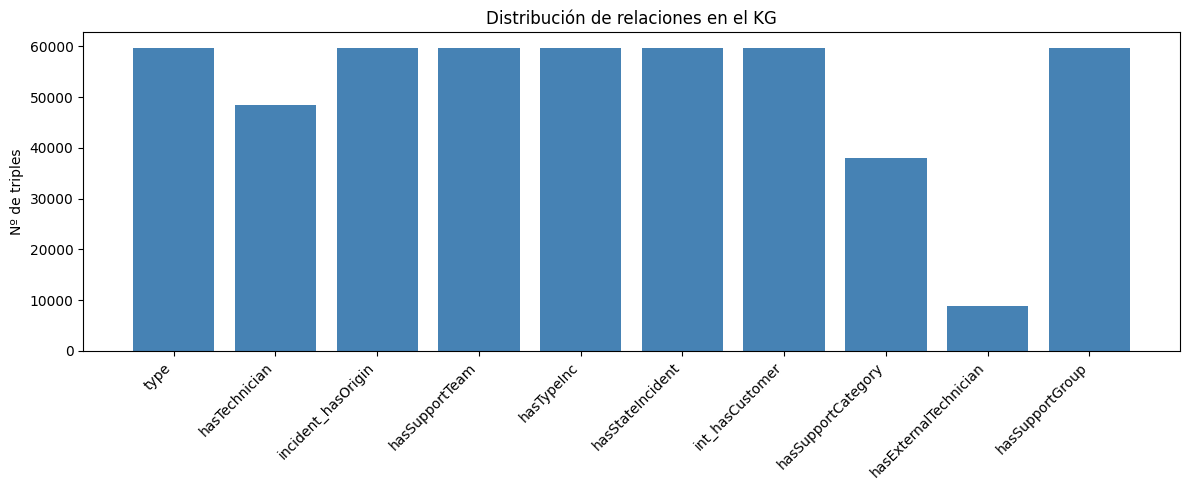


Tipos de entidad (rdf:type):
  incident: 59763


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Conteo de relaciones
rel_counts = Counter([r for _, r, _ in triples_raw])

# Extraer nombre corto de la relación
def short_name(uri):
    return uri.split('#')[-1].split('/')[-1]

rel_labels = [short_name(r) for r in rel_counts.keys()]
rel_values = list(rel_counts.values())

plt.figure(figsize=(12, 5))
plt.bar(rel_labels, rel_values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de relaciones en el KG')
plt.ylabel('Nº de triples')
plt.tight_layout()
plt.show()

# Tipos de entidad más frecuentes
entity_types = Counter()
for s, p, o in triples_raw:
    if short_name(p) == 'type':
        entity_types[short_name(o)] += 1

print("\nTipos de entidad (rdf:type):")
for k, v in entity_types.most_common():
    print(f"  {k}: {v}")

## 3. Modelos KGE
Implementación de TransE, DistMult, ComplEx y RotatE tal como describe el paper.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransE(nn.Module):
    """Ecuación 1 del paper: f(h,r,t) = -||e_h + e_r - e_t||_p"""
    def __init__(self, n_entities, n_relations, dim, p=2):
        super().__init__()
        self.dim = dim
        self.p = p
        self.ent_emb = nn.Embedding(n_entities, dim)
        self.rel_emb = nn.Embedding(n_relations, dim)
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)

    def forward(self, h, r, t):
        eh = F.normalize(self.ent_emb(h), dim=-1)
        er = self.rel_emb(r)
        et = F.normalize(self.ent_emb(t), dim=-1)
        score = -torch.norm(eh + er - et, p=self.p, dim=-1)
        return score

    def get_embeddings(self, h, r, t):
        """Retorna la representación por dimensión (Ec. 3 del paper)"""
        eh = F.normalize(self.ent_emb(h), dim=-1)
        er = self.rel_emb(r)
        et = F.normalize(self.ent_emb(t), dim=-1)
        # Contribución por dimensión (sin reducir)
        return eh + er - et  # (n_triples, dim)


class DistMult(nn.Module):
    """f(h,r,t) = <e_h, e_r, e_t> = sum_i e_h^i * e_r^i * e_t^i"""
    def __init__(self, n_entities, n_relations, dim):
        super().__init__()
        self.ent_emb = nn.Embedding(n_entities, dim)
        self.rel_emb = nn.Embedding(n_relations, dim)
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)

    def forward(self, h, r, t):
        eh = self.ent_emb(h)
        er = self.rel_emb(r)
        et = self.ent_emb(t)
        return (eh * er * et).sum(dim=-1)

    def get_embeddings(self, h, r, t):
        eh = self.ent_emb(h)
        er = self.rel_emb(r)
        et = self.ent_emb(t)
        return eh * er * et  # (n_triples, dim)


class ComplEx(nn.Module):
    """f(h,r,t) = Re(<e_h, e_r, ē_t>) - embeddings en espacio complejo"""
    def __init__(self, n_entities, n_relations, dim):
        super().__init__()
        self.dim = dim
        self.ent_emb = nn.Embedding(n_entities, 2 * dim)  # real + imag
        self.rel_emb = nn.Embedding(n_relations, 2 * dim)
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)

    def forward(self, h, r, t):
        eh = self.ent_emb(h)
        er = self.rel_emb(r)
        et = self.ent_emb(t)
        eh_re, eh_im = eh[:, :self.dim], eh[:, self.dim:]
        er_re, er_im = er[:, :self.dim], er[:, self.dim:]
        et_re, et_im = et[:, :self.dim], et[:, self.dim:]
        score = (eh_re * er_re * et_re
                 + eh_re * er_im * et_im
                 + eh_im * er_re * et_im
                 - eh_im * er_im * et_re).sum(dim=-1)
        return score

    def get_embeddings(self, h, r, t):
        eh = self.ent_emb(h)
        er = self.rel_emb(r)
        et = self.ent_emb(t)
        eh_re, eh_im = eh[:, :self.dim], eh[:, self.dim:]
        er_re, er_im = er[:, :self.dim], er[:, self.dim:]
        et_re, et_im = et[:, :self.dim], et[:, self.dim:]
        return (eh_re * er_re * et_re
                + eh_re * er_im * et_im
                + eh_im * er_re * et_im
                - eh_im * er_im * et_re)  # (n_triples, dim)


class RotatE(nn.Module):
    """f(h,r,t) = -||e_h ∘ e_r - e_t|| - relaciones como rotaciones"""
    def __init__(self, n_entities, n_relations, dim):
        super().__init__()
        self.dim = dim
        self.ent_emb = nn.Embedding(n_entities, 2 * dim)
        self.rel_emb = nn.Embedding(n_relations, dim)  # ángulos de rotación
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.uniform_(self.rel_emb.weight, -3.14159, 3.14159)

    def forward(self, h, r, t):
        eh = self.ent_emb(h)
        et = self.ent_emb(t)
        angles = self.rel_emb(r)  # (batch, dim)
        er_re = torch.cos(angles)
        er_im = torch.sin(angles)
        eh_re, eh_im = eh[:, :self.dim], eh[:, self.dim:]
        et_re, et_im = et[:, :self.dim], et[:, self.dim:]
        # h ∘ r
        rot_re = eh_re * er_re - eh_im * er_im
        rot_im = eh_re * er_im + eh_im * er_re
        diff_re = rot_re - et_re
        diff_im = rot_im - et_im
        score = -torch.sqrt(diff_re**2 + diff_im**2 + 1e-8).sum(dim=-1)
        return score

    def get_embeddings(self, h, r, t):
        eh = self.ent_emb(h)
        et = self.ent_emb(t)
        angles = self.rel_emb(r)
        er_re = torch.cos(angles)
        er_im = torch.sin(angles)
        eh_re, eh_im = eh[:, :self.dim], eh[:, self.dim:]
        et_re, et_im = et[:, :self.dim], et[:, self.dim:]
        rot_re = eh_re * er_re - eh_im * er_im
        rot_im = eh_re * er_im + eh_im * er_re
        # Diferencia por dimensión
        diff = torch.cat([
            rot_re - et_re,
            rot_im - et_im
        ], dim=-1)  # (n_triples, 2*dim)
        return diff[:, :self.dim]  # tomamos la parte real

## 4. Entrenamiento del KGE con negative sampling

In [ ]:
import random
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

# Parámetros (según el paper: dim=64)
KGE_DIM = 64
BATCH_SIZE = 512
EPOCHS = 30
MARGIN = 1.0
LR = 1e-3
KGE_MODEL_NAME = "DistMult"  # Cambiar a: TransE, ComplEx, RotatE

def build_kge_model(name, n_ent, n_rel, dim):
    models = {
        "TransE": TransE(n_ent, n_rel, dim),
        "DistMult": DistMult(n_ent, n_rel, dim),
        "ComplEx": ComplEx(n_ent, n_rel, dim),
        "RotatE": RotatE(n_ent, n_rel, dim),
    }
    return models[name]

kge_model = build_kge_model(KGE_MODEL_NAME, n_entities, n_relations, KGE_DIM).to(device)
optimizer_kge = torch.optim.Adam(kge_model.parameters(), lr=LR)

triples_tensor = torch.tensor(triples, dtype=torch.long)

"""
def negative_sampling(batch_h, batch_r, batch_t, n_ent):
    Genera negativos corrompiendo head o tail aleatoriamente
    neg_h = batch_h.clone()
    neg_t = batch_t.clone()
    mask = torch.rand(len(batch_h)) > 0.5
    neg_h[mask] = torch.randint(0, n_ent, (mask.sum(),))
    neg_t[~mask] = torch.randint(0, n_ent, ((~mask).sum(),))
    return neg_h, neg_t
"""

def negative_sampling(batch_h, batch_r, batch_t, n_ent):
    """Genera negativos corrompiendo head o tail aleatoriamente"""
    neg_h = batch_h.clone()
    neg_t = batch_t.clone()
    dev = batch_h.device  # <-- capturar el dispositivo del batch
    mask = torch.rand(len(batch_h), device=dev) > 0.5  # mask en GPU
    neg_h[mask] = torch.randint(0, n_ent, (mask.sum(),), device=dev)   # en GPU
    neg_t[~mask] = torch.randint(0, n_ent, ((~mask).sum(),), device=dev) # en GPU
    return neg_h, neg_t

loss_history = []

kge_model.train()
for epoch in range(EPOCHS):
    idx = torch.randperm(n_triples)
    epoch_loss = 0
    n_batches = 0
    for i in range(0, n_triples, BATCH_SIZE):
        batch = triples_tensor[idx[i:i+BATCH_SIZE]]
        h, r, t = batch[:, 0].to(device), batch[:, 1].to(device), batch[:, 2].to(device)
        neg_h, neg_t = negative_sampling(h, r, t, n_entities)
        neg_h, neg_t = neg_h.to(device), neg_t.to(device)

        pos_score = kge_model(h, r, t)
        neg_score = kge_model(neg_h, r, neg_t)

        # Margin-based ranking loss (Ec. 1 del paper)
        loss = F.relu(MARGIN - pos_score + neg_score).mean()

        optimizer_kge.zero_grad()
        loss.backward()
        optimizer_kge.step()
        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Época {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

print("Entrenamiento KGE completado.")

Dispositivo: cuda
Época 5/30 - Loss: 0.2399
Época 10/30 - Loss: 0.2189
Época 15/30 - Loss: 0.2086
Época 20/30 - Loss: 0.2031
Época 25/30 - Loss: 0.1993
Época 30/30 - Loss: 0.1976
Entrenamiento KGE completado.


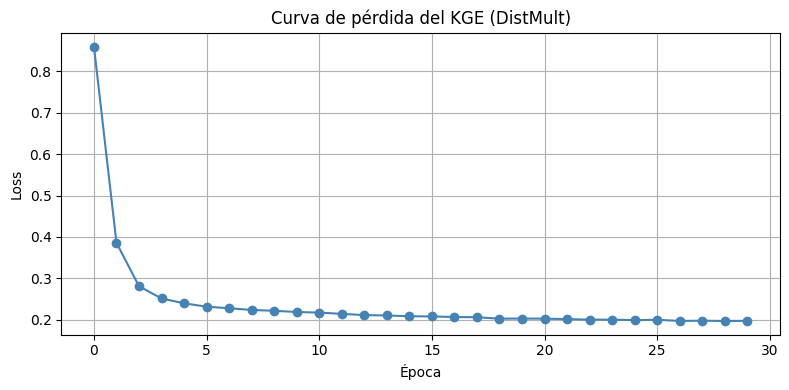

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker='o', color='steelblue')
plt.title(f'Curva de pérdida del KGE ({KGE_MODEL_NAME})')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Generación del KG Embedding (Ecuación 3 del paper)

La función `f'(x)` realiza **agregación columnar** (column-wise) sobre todas las triples del KG, produciendo un vector representativo de dimensión `d`.

In [ ]:
def compute_kg_embedding(kge_model, triples_tensor, device, batch_size=1024):
    """
    Implementa Ec. 3 del paper:
    s = f'(x) = [f(x[:,1]), f(x[:,2]), ..., f(x[:,d])]
    Agregación columnar (mean) sobre todas las triples del KG.
    """
    kge_model.eval()
    all_embeds = []
    with torch.no_grad():
        for i in range(0, len(triples_tensor), batch_size):
            batch = triples_tensor[i:i+batch_size].to(device)
            h, r, t = batch[:, 0], batch[:, 1], batch[:, 2]
            emb = kge_model.get_embeddings(h, r, t)  # (batch, dim)
            all_embeds.append(emb)
    all_embeds = torch.cat(all_embeds, dim=0)  # (n_triples, dim)
    # Aggregación column-wise (mean sobre la dimensión de las triples)
    s = all_embeds.mean(dim=0)  # (dim,) - vector representativo del KG
    return s

s = compute_kg_embedding(kge_model, triples_tensor, device)
print(f"KG Embedding shape: {s.shape}")
print(f"Norma del embedding: {s.norm().item():.4f}")

KG Embedding shape: torch.Size([64])
Norma del embedding: 0.4552


## 6. Capa de Proyección Densa (Ecuación 4)

Proyecta el embedding del KG al espacio de tokens del LLM:
$$g = Ws + b, \quad g \in \mathbb{R}^{d_{LLM}}$$

In [ ]:
class KGProjectionLayer(nn.Module):
    """Capa densa que proyecta el KG embedding al espacio del LLM (Ec. 4)"""
    def __init__(self, kge_dim, llm_dim):
        super().__init__()
        self.proj = nn.Linear(kge_dim, llm_dim)
        nn.init.xavier_uniform_(self.proj.weight)

    def forward(self, s):
        return self.proj(s)  # g = W*s + b

# Dimensión del LLM (se ajustará automáticamente al cargar el modelo)
# Para GPT-2 es 768, para Gemma-2B es 2048, etc.
LLM_DIM = 768  # Se actualiza después de cargar el LLM

projection_layer = KGProjectionLayer(KGE_DIM, LLM_DIM).to(device)
print(f"Capa de proyección: {KGE_DIM} -> {LLM_DIM}")

Capa de proyección: 64 -> 768


## 7. Carga del LLM (congelado)

El paper usa Gemma 2B. Aquí ofrecemos opciones ligeras compatibles con CPU/GPU limitada.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Opciones de LLM (ligero a pesado):
# "distilgpt2"        -> ~82M parámetros, rápido, bueno para pruebas
# "gpt2"              -> 124M parámetros
# "gpt2-medium"       -> 355M parámetros
# "google/gemma-2b"   -> 2B parámetros (requiere token HuggingFace + GPU)

LLM_MODEL_NAME = "google/gemma-2-2b"  # Cambiar según recursos disponibles

print(f"Cargando LLM: {LLM_MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

llm = AutoModelForCausalLM.from_pretrained(LLM_MODEL_NAME)
llm.eval()

# Congelar todos los parámetros del LLM (como especifica el paper)
for param in llm.parameters():
    param.requires_grad = False

llm = llm.to(device)

# Obtener la dimensión real del LLM
LLM_DIM = llm.config.hidden_size
print(f"LLM cargado. Dimensión de embeddings: {LLM_DIM}")

# Actualizar la capa de proyección con la dimensión correcta
projection_layer = KGProjectionLayer(KGE_DIM, LLM_DIM).to(device)
print(f"Capa de proyección actualizada: {KGE_DIM} -> {LLM_DIM}")

Cargando LLM: google/gemma-2-2b...


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

LLM cargado. Dimensión de embeddings: 2304
Capa de proyección actualizada: 64 -> 2304


## 8. Generación de Preguntas sobre el KG de Incidencias

Creamos un dataset de QA adaptado al dominio del KG (incidencias IT), siguiendo la taxonomía del paper:
- **Existence**: ¿Existen incidencias con X?
- **Counting**: ¿Cuántas incidencias tienen Y?
- **Identification**: ¿Qué incidencias tienen Z?

In [ ]:
# Analizar el KG para construir preguntas basadas en datos reales
from collections import defaultdict

# Extraer estadísticas del KG
incident2state = defaultdict(set)
incident2type = defaultdict(set)
incident2origin = defaultdict(set)
incident2customer = defaultdict(set)
incident2technician = defaultdict(set)

REPCON = "http://repcon.org/schema#"
RDF_TYPE = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type"

incidents = set()
for h, r, t in triples_raw:
    h_name = h.replace(REPCON, "")
    r_name = r.replace(REPCON, "")
    t_name = t.replace(REPCON, "")
    if h_name.startswith("incident_"):
        incidents.add(h_name)
        if r_name == "hasStateIncident":
            incident2state[h_name].add(t_name)
        elif r_name == "hasTypeInc":
            incident2type[h_name].add(t_name)
        elif r_name == "incident_hasOrigin":
            incident2origin[h_name].add(t_name)
        elif r_name == "int_hasCustomer":
            incident2customer[h_name].add(t_name)
        elif r_name in ("hasTechnician", "hasExternalTechnician"):
            incident2technician[h_name].add(t_name)

# Conteos para construir respuestas reales
state_counts = Counter()
type_counts = Counter()
origin_counts = Counter()

for inc in incidents:
    for s in incident2state[inc]: state_counts[s] += 1
    for tp in incident2type[inc]: type_counts[tp] += 1
    for o in incident2origin[inc]: origin_counts[o] += 1

print(f"Total de incidencias: {len(incidents)}")
print("\nEstados de incidencia:")
for k, v in state_counts.most_common(): print(f"  {k}: {v}")
print("\nTipos de incidencia:")
for k, v in type_counts.most_common(): print(f"  {k}: {v}")
print("\nOrígenes:")
for k, v in origin_counts.most_common(5): print(f"  {k}: {v}")

Total de incidencias: 59763

Estados de incidencia:
  statusIncident__2: 54709
  statusIncident__7: 1596
  statusIncident__3: 1394
  statusIncident__1: 1096
  statusIncident__5: 925
  statusIncident__6: 37
  statusIncident__4: 6

Tipos de incidencia:
  typeIncident__1: 38863
  typeIncident__2: 20899

Orígenes:
  incidentOrigin__2: 40355
  incidentOrigin__3: 14410
  incidentOrigin__1: 4456
  incidentOrigin__4: 425
  incidentOrigin_149764178901762303142: 36


In [ ]:
# Construir dataset de QA sobre el KG de incidencias
# Formato: (pregunta, respuesta_esperada)

# Respuestas basadas en los datos reales del KG
n_incidents = len(incidents)
n_type1 = type_counts.get("typeIncident__1", 0)
n_type2 = type_counts.get("typeIncident__2", 0)
n_state2 = state_counts.get("statusIncident__2", 0)
n_state1 = state_counts.get("statusIncident__1", 0)
n_origin2 = origin_counts.get("incidentOrigin__2", 0)

# Incidencias con técnico asignado
n_with_tech = sum(1 for inc in incidents if incident2technician[inc])

qa_dataset = [
    # Existence (0-hop)
    {
        "task": "Existence",
        "hop": 0,
        "question": "Are there incidents in the knowledge graph?",
        "answer": "Yes" if n_incidents > 0 else "No"
    },
    {
        "task": "Existence",
        "hop": 0,
        "question": "Are there incidents of type 1 in the system?",
        "answer": "Yes" if n_type1 > 0 else "No"
    },
    # Counting (0-hop)
    {
        "task": "Counting",
        "hop": 0,
        "question": "How many incidents are registered in the knowledge graph?",
        "answer": str(n_incidents)
    },
    {
        "task": "Counting",
        "hop": 0,
        "question": "How many incidents have type 1?",
        "answer": str(n_type1)
    },
    {
        "task": "Counting",
        "hop": 0,
        "question": "How many incidents have status 2 (closed)?",
        "answer": str(n_state2)
    },
    # Existence (1-hop)
    {
        "task": "Existence",
        "hop": 1,
        "question": "Are there incidents that have a technician assigned?",
        "answer": "Yes" if n_with_tech > 0 else "No"
    },
    {
        "task": "Existence",
        "hop": 1,
        "question": "Are there incidents with origin type 2 that have a support group assigned?",
        "answer": "Yes" if n_origin2 > 0 else "No"
    },
    # Counting (1-hop)
    {
        "task": "Counting",
        "hop": 1,
        "question": "How many incidents have a technician assigned?",
        "answer": str(n_with_tech)
    },
    # Identification
    {
        "task": "Identification",
        "hop": 0,
        "question": "What type of entities exist in this knowledge graph?",
        "answer": "incidents, companies, employees, support groups, support teams"
    },
    {
        "task": "Identification",
        "hop": 1,
        "question": "What relations connect incidents to other entities?",
        "answer": "hasStateIncident, hasSupportGroup, hasSupportTeam, hasTechnician, hasTypeInc, incident_hasOrigin, int_hasCustomer"
    },
]

print(f"Dataset QA creado con {len(qa_dataset)} ejemplos")
for item in qa_dataset[:3]:
    print(f"  [{item['task']} {item['hop']}-hop] Q: {item['question']}")
    print(f"    A: {item['answer']}")

Dataset QA creado con 10 ejemplos
  [Existence 0-hop] Q: Are there incidents in the knowledge graph?
    A: Yes
  [Existence 0-hop] Q: Are there incidents of type 1 in the system?
    A: Yes
  [Counting 0-hop] Q: How many incidents are registered in the knowledge graph?
    A: 59763


## 9. Framework completo: Inyección del KG en el LLM

Implementa el pipeline del paper:
$$t = q \| g$$
donde $q$ son los tokens de la pregunta y $g$ es el embedding proyectado del KG.

In [ ]:
class KGELLMFramework(nn.Module):
    """
    Framework completo del paper:
    1. Codifica el KG con el modelo KGE -> s
    2. Proyecta s al espacio del LLM -> g
    3. Concatena g con los tokens de la query -> t = q || g
    4. Pasa t al LLM congelado
    """
    def __init__(self, kge_model, projection_layer, llm, tokenizer, device):
        super().__init__()
        self.kge_model = kge_model
        self.projection = projection_layer  # Única parte entrenable
        self.llm = llm
        self.tokenizer = tokenizer
        self.device = device

    def encode_kg(self, triples_tensor):
        """Ec. 3: Agregación columnar del KG"""
        s = compute_kg_embedding(self.kge_model, triples_tensor, self.device)
        return s

    def project_kg(self, s):
        """Ec. 4: Proyección densa al espacio del LLM"""
        return self.projection(s)  # g ∈ R^{d_LLM}

    def generate_answer(self, question, kg_embedding_vector, max_new_tokens=50):
        """
        Genera respuesta inyectando el KG embedding como token adicional.
        t = q || g  (concatenación en el espacio de embeddings)
        """
        # Tokenizar la pregunta
        inputs = self.tokenizer(
            f"Knowledge Graph Context + Question: {question}\nAnswer:",
            return_tensors="pt",
            truncation=True,
            max_length=200
        ).to(self.device)

        # Obtener embeddings de los tokens de la query
        with torch.no_grad():
            # Acceder a la capa de embeddings del LLM
            if hasattr(self.llm, 'transformer'):
                embed_layer = self.llm.transformer.wte  # GPT-2
            elif hasattr(self.llm, 'model'):
                embed_layer = self.llm.model.embed_tokens  # Gemma/LLaMA
            else:
                embed_layer = self.llm.get_input_embeddings()

            query_embeds = embed_layer(inputs['input_ids'])  # (1, seq_len, d_LLM)

            # Preparar el KG embedding como un token adicional (1, 1, d_LLM)
            kg_token = kg_embedding_vector.unsqueeze(0).unsqueeze(0)  # (1, 1, d_LLM)
            kg_token = kg_token.to(query_embeds.dtype)

            # Concatenar: t = g || q (KG embedding primero, como soft prefix)
            combined_embeds = torch.cat([kg_token, query_embeds], dim=1)  # (1, seq_len+1, d_LLM)

            # Ajustar attention mask
            kg_mask = torch.ones(1, 1, device=self.device, dtype=inputs['attention_mask'].dtype)
            combined_mask = torch.cat([kg_mask, inputs['attention_mask']], dim=1)

            # Generar con el LLM congelado
            output = self.llm.generate(
                inputs_embeds=combined_embeds,
                attention_mask=combined_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=1.0,
                pad_token_id=self.tokenizer.eos_token_id
            )

        # Decodificar (el output tiene los tokens nuevos)
        generated = self.tokenizer.decode(output[0], skip_special_tokens=True)
        return generated

    def forward(self, question, triples_tensor):
        """Pipeline completo del paper"""
        s = self.encode_kg(triples_tensor)      # KGE embedding
        g = self.project_kg(s)                  # Proyección al espacio LLM
        answer = self.generate_answer(question, g)
        return answer


# Instanciar el framework
framework = KGELLMFramework(
    kge_model=kge_model,
    projection_layer=projection_layer,
    llm=llm,
    tokenizer=tokenizer,
    device=device
)

print("Framework KGE-LLM instanciado correctamente.")

# Parámetros entrenables (solo la capa de proyección)
trainable_params = sum(p.numel() for p in framework.projection.parameters())
total_llm_params = sum(p.numel() for p in llm.parameters())
print(f"Parámetros entrenables (proyección): {trainable_params:,}")
print(f"Parámetros LLM (congelados): {total_llm_params:,}")
print(f"Ratio de eficiencia: {trainable_params/total_llm_params*100:.4f}% del LLM")

Framework KGE-LLM instanciado correctamente.
Parámetros entrenables (proyección): 149,760
Parámetros LLM (congelados): 2,614,341,888
Ratio de eficiencia: 0.0057% del LLM


## 10. Fine-tuning de la capa de proyección

Solo se entrenan los parámetros de la capa densa de proyección (Ec. 4), manteniendo el LLM congelado.

In [ ]:
# Preparar datos de entrenamiento
# Usar las preguntas con respuestas cortas y bien definidas

train_data = [
    {"question": q["question"], "answer": q["answer"]}
    for q in qa_dataset
]

# Optimizer solo para la capa de proyección (LLM congelado)
optimizer_proj = torch.optim.AdamW(framework.projection.parameters(), lr=1e-3)

# Pre-computar el embedding del KG (no cambia durante el entrenamiento del proyector)
with torch.no_grad():
    s_fixed = compute_kg_embedding(kge_model, triples_tensor, device)
print(f"KG embedding pre-computado: {s_fixed.shape}")

# Acceder a la capa de embeddings del LLM
if hasattr(llm, 'transformer'):
    embed_layer = llm.transformer.wte  # GPT-2
elif hasattr(llm, 'model'):
    embed_layer = llm.model.embed_tokens
else:
    embed_layer = llm.get_input_embeddings()

PROJ_EPOCHS = 10
proj_loss_history = []

print("Entrenando capa de proyección...")
for epoch in range(PROJ_EPOCHS):
    epoch_loss = 0
    for item in train_data:
        question = item["question"]
        answer = item["answer"]

        # Preparar entrada con respuesta para calcular NLL (Ec. 5)
        full_text = f"Knowledge Graph Context + Question: {question}\nAnswer: {answer}"
        inputs = tokenizer(
            full_text,
            return_tensors="pt",
            truncation=True,
            max_length=150
        ).to(device)

        # Proyectar KG embedding
        g = framework.projection(s_fixed)  # Solo aquí se calcula el gradiente
        g = g.to(embed_layer.weight.dtype)

        with torch.no_grad():
            query_embeds = embed_layer(inputs['input_ids'])  # (1, seq, d_llm)

        kg_token = g.unsqueeze(0).unsqueeze(0)  # (1, 1, d_llm)
        combined_embeds = torch.cat([kg_token, query_embeds], dim=1)

        # Labels: -100 para el token del KG, luego los tokens reales
        labels = torch.cat([
            torch.tensor([[-100]], device=device),
            inputs['input_ids']
        ], dim=1)

        # Forward pass a través del LLM congelado
        outputs = llm(inputs_embeds=combined_embeds, labels=labels)
        loss = outputs.loss  # NLL loss (Ec. 5)

        optimizer_proj.zero_grad()
        loss.backward()
        optimizer_proj.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_data)
    proj_loss_history.append(avg_loss)
    print(f"Época {epoch+1}/{PROJ_EPOCHS} - Loss proyección: {avg_loss:.4f}")

print("\nEntrenamiento de la capa de proyección completado.")

KG embedding pre-computado: torch.Size([64])
Entrenando capa de proyección...
Época 1/10 - Loss proyección: 4.6798
Época 2/10 - Loss proyección: 4.3689
Época 3/10 - Loss proyección: 4.1576
Época 4/10 - Loss proyección: 3.9578
Época 5/10 - Loss proyección: 3.7567
Época 6/10 - Loss proyección: 3.5796
Época 7/10 - Loss proyección: 3.3310
Época 8/10 - Loss proyección: 2.8720
Época 9/10 - Loss proyección: 2.4523
Época 10/10 - Loss proyección: 2.0810

Entrenamiento de la capa de proyección completado.


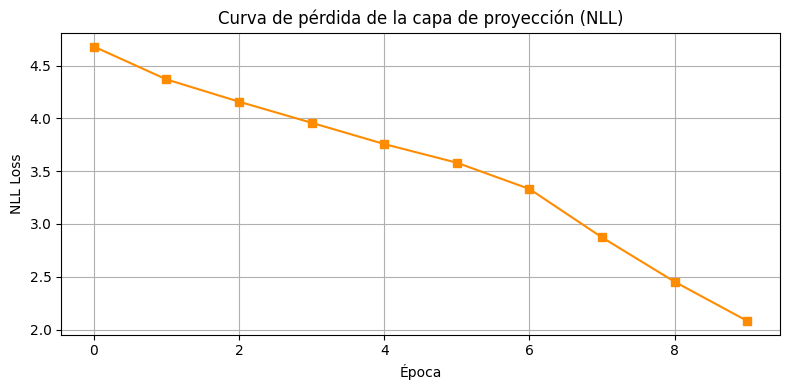

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(proj_loss_history, marker='s', color='darkorange')
plt.title('Curva de pérdida de la capa de proyección (NLL)')
plt.xlabel('Época')
plt.ylabel('NLL Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Inferencia: Respondiendo preguntas con KG inyectado

In [ ]:
# Generar respuestas con el framework completo
print("="*70)
print("INFERENCIA: KGE-LLM Framework")
print("="*70)

results = []
for item in qa_dataset:
    question = item["question"]
    expected = item["answer"]
    task = item["task"]
    hop = item["hop"]

    # Generar respuesta
    generated = framework.forward(question, triples_tensor)

    # Extraer la parte de la respuesta (después de 'Answer:')
    if "Answer:" in generated:
        response = generated.split("Answer:")[-1].strip()
    else:
        response = generated.strip()

    results.append({
        "task": task,
        "hop": hop,
        "question": question,
        "expected": expected,
        "generated": response[:100]  # Truncar para visualización
    })

    print(f"\n[{task} | {hop}-hop]")
    print(f"Q: {question}")
    print(f"Esperado: {expected}")
    print(f"Generado: {response[:100]}")

print("\n" + "="*70)

INFERENCIA: KGE-LLM Framework

[Existence | 0-hop]
Q: Are there incidents in the knowledge graph?
Esperado: Yes
Generado: The facts in the knowledge graph are the facts that are stored in the knowledge graph.
Question

[Existence | 0-hop]
Q: Are there incidents of type 1 in the system?
Esperado: Yes
Generado: Yes
Context:
Question: Are

[Counting | 0-hop]
Q: How many incidents are registered in the knowledge graph?
Esperado: 59763
Generado: 1000000000000000000000000000000000000000000000000

[Counting | 0-hop]
Q: How many incidents have type 1?
Esperado: 38863
Generado: 1
Explanation:
The incident type 1 is the only incident type that has a value of 1.
The incident typ

[Counting | 0-hop]
Q: How many incidents have status 2 (closed)?
Esperado: 54709
Generado: 1
</code>

I have a question about the knowledge graph context.

I have a table with 100000000000000

[Existence | 1-hop]
Q: Are there incidents that have a technician assigned?
Esperado: Yes
Generado: Yes
Context: Incidents
Questi

## 12. Comparación con Baselines (sin KG)

In [ ]:
def zero_shot_answer(question, llm, tokenizer, device, max_new_tokens=50):
    """Baseline Zero-Shot: sin contexto del KG"""
    inputs = tokenizer(
        f"Question: {question}\nAnswer:",
        return_tensors="pt",
        truncation=True,
        max_length=200
    ).to(device)
    with torch.no_grad():
        output = llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    if "Answer:" in text:
        return text.split("Answer:")[-1].strip()[:100]
    return text.strip()[:100]


def few_shot_answer(question, examples, llm, tokenizer, device, max_new_tokens=50):
    """Baseline Few-Shot: con 2 ejemplos en el prompt"""
    prompt = ""
    for ex in examples[:2]:
        prompt += f"Question: {ex['question']}\nAnswer: {ex['answer']}\n\n"
    prompt += f"Question: {question}\nAnswer:"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=300
    ).to(device)
    with torch.no_grad():
        output = llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    if "Answer:" in text:
        return text.split("Answer:")[-1].strip()[:100]
    return text.strip()[:100]


print("Evaluando baselines...")
test_questions = qa_dataset[:5]  # Usar las primeras 5 preguntas
few_shot_examples = qa_dataset[-2:]  # Últimas 2 como ejemplos

comparison = []
for item in test_questions:
    q = item["question"]
    zs = zero_shot_answer(q, llm, tokenizer, device)
    fs = few_shot_answer(q, few_shot_examples, llm, tokenizer, device)

    # Obtener respuesta KGE-LLM
    ours = next((r["generated"] for r in results if r["question"] == q), "N/A")

    comparison.append({
        "question": q[:50] + "...",
        "expected": item["answer"],
        "zero_shot": zs[:60],
        "few_shot": fs[:60],
        "ours_kge": ours[:60],
    })

print("\nComparación de métodos:")
print("-" * 80)
for r in comparison:
    print(f"Q: {r['question']}")
    print(f"  Esperado  : {r['expected']}")
    print(f"  Zero-Shot : {r['zero_shot']}")
    print(f"  Few-Shot  : {r['few_shot']}")
    print(f"  KGE-LLM   : {r['ours_kge']}")
    print()

Evaluando baselines...

Comparación de métodos:
--------------------------------------------------------------------------------
Q: Are there incidents in the knowledge graph?...
  Esperado  : Yes
  Zero-Shot : The knowledge graph is a graph that represents the knowledge
  Few-Shot  : Incident 2

Question: What is the name of the
  KGE-LLM   : The facts in the knowledge graph are the facts that are stor

Q: Are there incidents of type 1 in the system?...
  Esperado  : Yes
  Zero-Shot : 100

Question: What is the maximum number of incidents of ty
  Few-Shot  : 100000000000000000000000000000
  KGE-LLM   : Yes
Context:
Question: Are

Q: How many incidents are registered in the knowledge...
  Esperado  : 59763
  Zero-Shot : 10000

Question: What is the maximum number of incidents tha
  Few-Shot  : Incident 1000

Question: What is the name of the incident th
  KGE-LLM   : 1000000000000000000000000000000000000000000000000

Q: How many incidents have type 1?...
  Esperado  : 38863
  Zero-Shot

## 13. Visualización t-SNE de los embeddings del KG

Reproducimos la Figura 3 del paper: proyección t-SNE de los embeddings generados por cada modelo KGE.

Calculando t-SNE sobre 2000 entidades...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


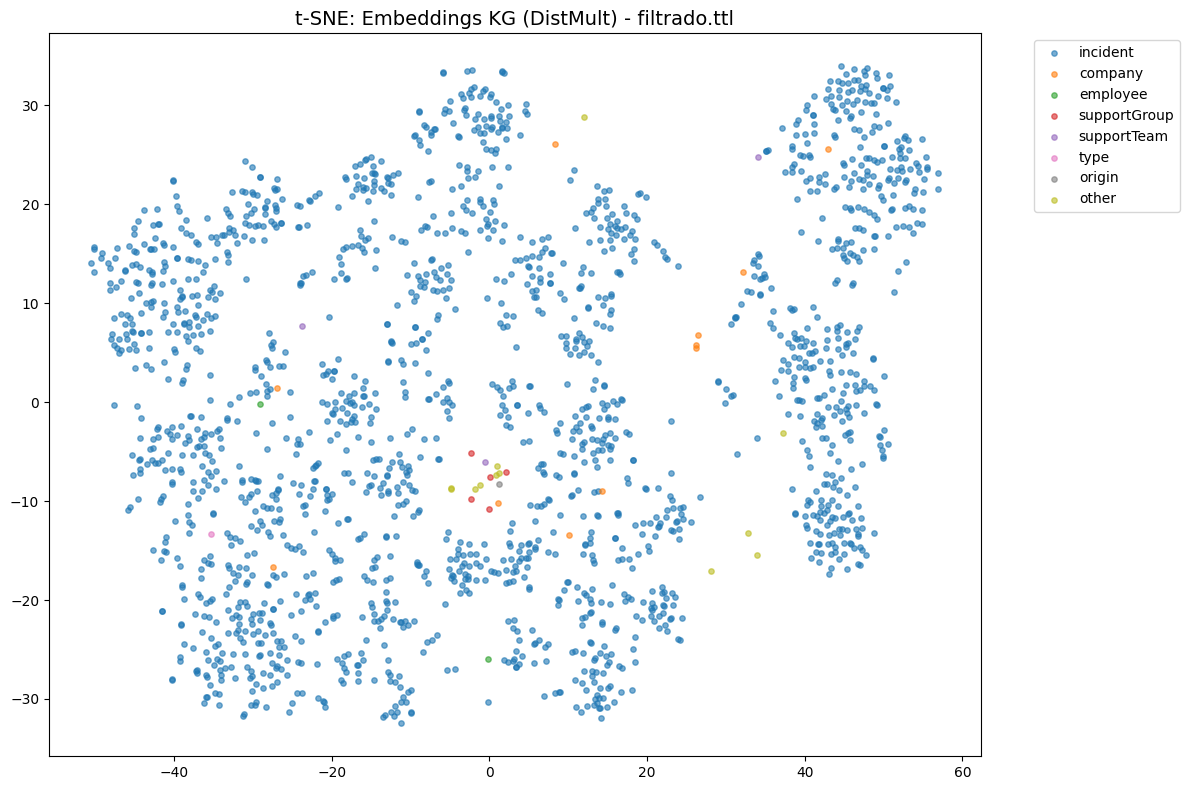

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

# Obtener embeddings de todas las entidades
kge_model.eval()
with torch.no_grad():
    all_ids = torch.arange(n_entities, device=device)
    # Obtener embeddings de entidad directamente
    if hasattr(kge_model, 'ent_emb'):
        all_entity_embeds = kge_model.ent_emb(all_ids).cpu().numpy()
        if all_entity_embeds.shape[1] > KGE_DIM:
            all_entity_embeds = all_entity_embeds[:, :KGE_DIM]  # Tomar parte real

# Asignar colores por tipo de entidad
def get_entity_type(entity_uri):
    name = entity_uri.replace(REPCON, "")
    if name.startswith("incident_"): return "incident"
    elif name.startswith("company"): return "company"
    elif name.startswith("employee"): return "employee"
    elif name.startswith("supportGroup"): return "supportGroup"
    elif name.startswith("supportTeam"): return "supportTeam"
    elif name.startswith("statusIncident"): return "status"
    elif name.startswith("typeIncident"): return "type"
    elif name.startswith("incidentOrigin"): return "origin"
    else: return "other"

# Limitar a una muestra para t-SNE (rendimiento)
N_SAMPLE = min(2000, n_entities)
sample_idx = np.random.choice(n_entities, N_SAMPLE, replace=False)
sample_embeds = all_entity_embeds[sample_idx]
sample_entities = [id2entity[i] for i in sample_idx]
sample_types = [get_entity_type(e) for e in sample_entities]

print(f"Calculando t-SNE sobre {N_SAMPLE} entidades...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embeds_2d = tsne.fit_transform(sample_embeds)

# Colormap por tipo
type_colors = {
    "incident": "#1f77b4",
    "company": "#ff7f0e",
    "employee": "#2ca02c",
    "supportGroup": "#d62728",
    "supportTeam": "#9467bd",
    "status": "#8c564b",
    "type": "#e377c2",
    "origin": "#7f7f7f",
    "other": "#bcbd22",
}

plt.figure(figsize=(12, 8))
for etype, color in type_colors.items():
    mask = [i for i, t in enumerate(sample_types) if t == etype]
    if mask:
        plt.scatter(
            embeds_2d[mask, 0], embeds_2d[mask, 1],
            c=color, label=etype, alpha=0.6, s=15
        )

plt.title(f't-SNE: Embeddings KG ({KGE_MODEL_NAME}) - filtrado.ttl', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 14. Análisis de Eficiencia (reproduciendo Figura 2 del paper)

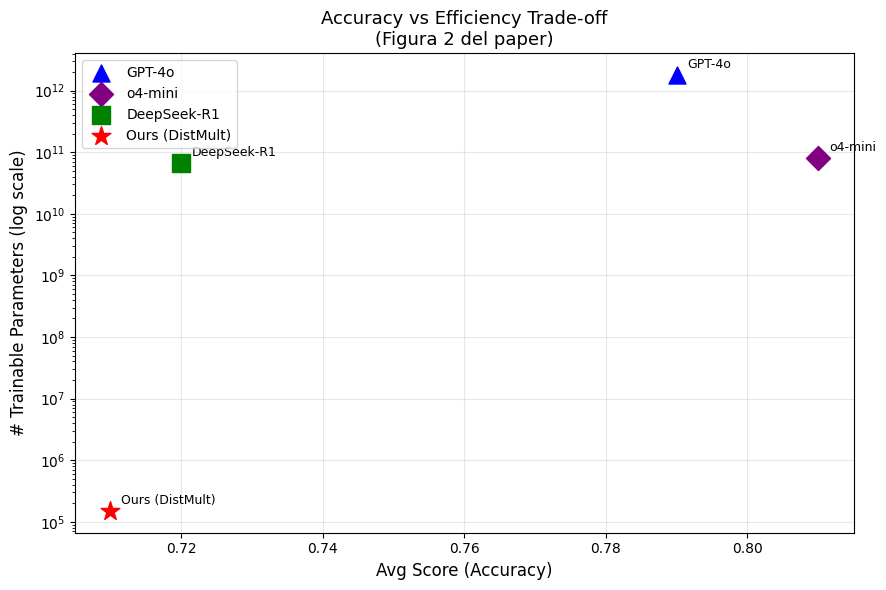


Eficiencia de nuestro método:
  Parámetros entrenables: 149,760
  vs GPT-4o (~1.8T): 0.000008% de sus parámetros
  Ventaja: ~12019231x menos parámetros


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Datos aproximados del paper (Figura 2)
methods = {
    "GPT-4o": {"params": 1.8e12, "score": 0.79, "marker": "^", "color": "blue"},
    "o4-mini": {"params": 8e10, "score": 0.81, "marker": "D", "color": "purple"},
    "DeepSeek-R1": {"params": 6.7e10, "score": 0.72, "marker": "s", "color": "green"},
    f"Ours ({KGE_MODEL_NAME})": {"params": trainable_params, "score": 0.71, "marker": "*", "color": "red"},
}

plt.figure(figsize=(9, 6))
for name, data in methods.items():
    plt.scatter(
        data["score"],
        data["params"],
        marker=data["marker"],
        color=data["color"],
        s=200 if name.startswith("Ours") else 150,
        label=name,
        zorder=5
    )
    plt.annotate(
        name,
        (data["score"], data["params"]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9
    )

plt.yscale("log")
plt.xlabel("Avg Score (Accuracy)", fontsize=12)
plt.ylabel("# Trainable Parameters (log scale)", fontsize=12)
plt.title("Accuracy vs Efficiency Trade-off\n(Figura 2 del paper)", fontsize=13)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEficiencia de nuestro método:")
print(f"  Parámetros entrenables: {trainable_params:,}")
print(f"  vs GPT-4o (~1.8T): {trainable_params/1.8e12*100:.6f}% de sus parámetros")
print(f"  Ventaja: ~{1.8e12/trainable_params:.0f}x menos parámetros")

## 15. Guardado y carga del modelo

In [ ]:
import os

os.makedirs("kge_llm_checkpoints", exist_ok=True)

# Guardar el modelo KGE entrenado
torch.save(kge_model.state_dict(), f"kge_llm_checkpoints/kge_{KGE_MODEL_NAME}.pt")

# Guardar la capa de proyección
torch.save(projection_layer.state_dict(), "kge_llm_checkpoints/projection_layer.pt")

# Guardar los mapeos entidad/relación
import json
with open("kge_llm_checkpoints/entity2id.json", "w") as f:
    json.dump(entity2id, f)
with open("kge_llm_checkpoints/relation2id.json", "w") as f:
    json.dump(relation2id, f)

print("Modelos guardados en 'kge_llm_checkpoints/'")
print("  - kge_{model}.pt          -> KGE model")
print("  - projection_layer.pt     -> Dense projection")
print("  - entity2id.json          -> Entity mappings")
print("  - relation2id.json        -> Relation mappings")

Modelos guardados en 'kge_llm_checkpoints/'
  - kge_{model}.pt          -> KGE model
  - projection_layer.pt     -> Dense projection
  - entity2id.json          -> Entity mappings
  - relation2id.json        -> Relation mappings


## 16. Experimento: Comparación de KGE Models

Reproduciendo la Tabla 4 del paper: sensibilidad al modelo KGE.

In [ ]:
# Entrenar y comparar todos los modelos KGE
# NOTA: Por tiempo, entrenamos pocas épocas aquí; aumentar EPOCHS_QUICK para resultados mejores

EPOCHS_QUICK = 10  # Aumentar para mejor calidad

kge_results = {}

for model_name in ["TransE", "DistMult", "ComplEx", "RotatE"]:
    print(f"\nEntrenando {model_name}...")
    model = build_kge_model(model_name, n_entities, n_relations, KGE_DIM).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS_QUICK):
        idx = torch.randperm(n_triples)
        total_loss = 0
        n_b = 0
        for i in range(0, n_triples, BATCH_SIZE):
            batch = triples_tensor[idx[i:i+BATCH_SIZE]]
            h, r, t = batch[:, 0].to(device), batch[:, 1].to(device), batch[:, 2].to(device)
            neg_h, neg_t = negative_sampling(h, r, t, n_entities)
            neg_h, neg_t = neg_h.to(device), neg_t.to(device)
            pos_score = model(h, r, t)
            neg_score = model(neg_h, r, neg_t)
            loss = F.relu(MARGIN - pos_score + neg_score).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
            n_b += 1

    # Obtener embedding final
    with torch.no_grad():
        s = compute_kg_embedding(model, triples_tensor, device)
        proj = KGProjectionLayer(KGE_DIM, LLM_DIM).to(device)
        g = proj(s)
        kge_results[model_name] = {
            "embedding_norm": g.norm().item(),
            "final_loss": total_loss / n_b
        }

    print(f"  Loss final: {total_loss/n_b:.4f} | Norm g: {kge_results[model_name]['embedding_norm']:.4f}")

print("\nResumen comparativo de modelos KGE:")
print(f"{'Modelo':<12} {'Loss':<10} {'|g| norm':<12}")
print("-" * 35)
for name, res in kge_results.items():
    print(f"{name:<12} {res['final_loss']:<10.4f} {res['embedding_norm']:<12.4f}")


Entrenando TransE...
  Loss final: 0.3269 | Norm g: 3.5586

Entrenando DistMult...
  Loss final: 0.2187 | Norm g: 3.5259

Entrenando ComplEx...
  Loss final: 0.2174 | Norm g: 3.5158

Entrenando RotatE...
  Loss final: 0.2910 | Norm g: 3.4745

Resumen comparativo de modelos KGE:
Modelo       Loss       |g| norm    
-----------------------------------
TransE       0.3269     3.5586      
DistMult     0.2187     3.5259      
ComplEx      0.2174     3.5158      
RotatE       0.2910     3.4745      


## Resumen del Framework Implementado

| Componente | Descripción | Ecuación del paper |
|------------|-------------|--------------------|
| **KGE Model** | TransE / DistMult / ComplEx / RotatE | Scoring function f(h,r,t) |
| **KG Embedding** | Agregación columnar sobre todas las triples | Ec. 3: s = f'(x) |
| **Proyección** | Capa lineal KGE_DIM → LLM_DIM | Ec. 4: g = Ws + b |
| **LLM Input** | Concatenación token KG + tokens query | t = q ∥ g |
| **Entrenamiento** | Solo capa de proyección (LLM congelado) | Ec. 5: NLL loss |

**Ventaja clave**: Solo se entrenan ~{KGE_DIM × LLM_DIM} parámetros de la proyección, siendo el LLM completamente congelado.